<a href="https://colab.research.google.com/github/Odeyiany2/ACCESS-6.0-Skills-Acquisition-Program-Data-Science/blob/main/week%203/Week_3_Session_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Week 3 Session 5 - Exploratory Data Analysis (EDA)**

### **Objectives**
- Perform univariate and bivariate analysis.
- Identify outliers and correlations.
- Answer business questions


### **Instructor Dataset:**
 [BudgetWise Personal Finance Dataset](https://www.kaggle.com/datasets/mohammedarfathr/budgetwise-personal-finance-dataset)




In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#getting the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#checking the files in my drive before reading the dataset
#!ls /content/drive/MyDrive/

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/budgetwise_cleaned.csv')
df.head() # Display the first few rows

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,year,month,month_name,day_of_week,quarter,spending_level,is_high_value,is_weekend,total_user_spending,avg_user_transaction
0,T4999,U018,2023-04-25,Expense,education,3888,card,ahmedabad,2023,4,April,Tuesday,2,Medium,False,False,759875,8259.510870
1,T12828,U133,2021-12-16,Expense,rent,649,Unknown,hyderabad,2021,12,December,Thursday,4,Small,False,False,998527,12030.445783
2,T7403,U091,2021-12-16,Income,freelance,13239,Csh,bangalore,2021,12,December,Thursday,4,Large,True,False,1127019,11500.193878
3,T7495,U088,2021-12-16,Expense,entertainment,2287,CARD,hyderabad,2021,12,December,Thursday,4,Medium,False,False,1144448,12439.652174
4,T12465,U042,2021-12-16,Expense,food,4168,Unknown,not specified,2021,12,December,Thursday,4,Medium,False,False,1015065,11803.081395


In [4]:
#summary of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13755 entries, 0 to 13754
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_id        13755 non-null  object 
 1   user_id               13755 non-null  object 
 2   date                  13755 non-null  object 
 3   transaction_type      13755 non-null  object 
 4   category              13755 non-null  object 
 5   amount                13755 non-null  int64  
 6   payment_mode          13755 non-null  object 
 7   location              13755 non-null  object 
 8   year                  13755 non-null  int64  
 9   month                 13755 non-null  int64  
 10  month_name            13755 non-null  object 
 11  day_of_week           13755 non-null  object 
 12  quarter               13755 non-null  int64  
 13  spending_level        13755 non-null  object 
 14  is_high_value         13755 non-null  bool   
 15  is_weekend         

In [5]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,0
amount,0
payment_mode,0
location,0
year,0
month,0


In [6]:
df.shape

(13755, 18)

In [7]:
#statistics summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount,13755.0,1.210255e+04,17244.765771,0.00000,2797.500000,5.784000e+03,9.372500e+03,7.999900e+04
year,13755.0,2.021595e+03,1.020487,2021.00000,2021.000000,2.021000e+03,2.022000e+03,2.024000e+03
month,13755.0,9.842312e+00,3.454275,1.00000,8.000000,1.200000e+01,1.200000e+01,1.200000e+01
quarter,13755.0,3.413377e+00,1.013919,1.00000,3.000000,4.000000e+00,4.000000e+00,4.000000e+00
total_user_spending,13755.0,1.119609e+06,195890.690972,723238.00000,998527.000000,1.111502e+06,1.261749e+06,1.813038e+06
avg_user_transaction,13755.0,1.210255e+04,1822.250073,8259.51087,10851.829545,1.203279e+04,1.326523e+04,1.694428e+04


In [9]:
#columns
df.columns.to_list()

['transaction_id',
 'user_id',
 'date',
 'transaction_type',
 'category',
 'amount',
 'payment_mode',
 'location',
 'year',
 'month',
 'month_name',
 'day_of_week',
 'quarter',
 'spending_level',
 'is_high_value',
 'is_weekend',
 'total_user_spending',
 'avg_user_transaction']

In [10]:
numeric = df.columns[df.dtypes != "object"]
cat = df.columns[df.dtypes == "object"]

In [11]:
print(numeric)
print(cat)

Index(['amount', 'year', 'month', 'quarter', 'is_high_value', 'is_weekend',
       'total_user_spending', 'avg_user_transaction'],
      dtype='object')
Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'payment_mode', 'location', 'month_name', 'day_of_week',
       'spending_level'],
      dtype='object')


In [12]:
#checking the number of unique values in the categorical column
for col in cat:
  print(col, df[col].nunique())

transaction_id 12899
user_id 150
date 1429
transaction_type 2
category 15
payment_mode 20
location 11
month_name 12
day_of_week 7
spending_level 3


In [ ]:
# -----------------------
# 2) High-level summary
# -----------------------
print("\nNumeric summary (describe):")
display(df.describe().T)

In [ ]:
print("\nCategorical overview (top values):")
for col in ['category','payment_mode','location','spending_level']:
    if col in df.columns:
        print(f"\nTop values for {col}:")
        display(df[col].value_counts().head(10))

## **1. What is EDA?**
Exploratory Data Analysis (EDA) is the process of **investigating your dataset** before modeling.

You perform EDA to answer:
- What does the data look like?
- What patterns exist?
- Are there errors or outliers?
- What relationships exist between variables?
- What questions can this dataset answer?

**EDA helps you understand your data before you use it.**


## **2. Univariate Analysis**
Univariate analysis = analyzing **one column at a time**.

Why is it important?
- Helps identify distribution of values  
- Helps detect outliers  
- Shows frequency patterns  
- Helps understand spreads and central tendencies  

We will explore:
- Distribution of spending amounts  
- Frequency of categories  
- Payment method usage  

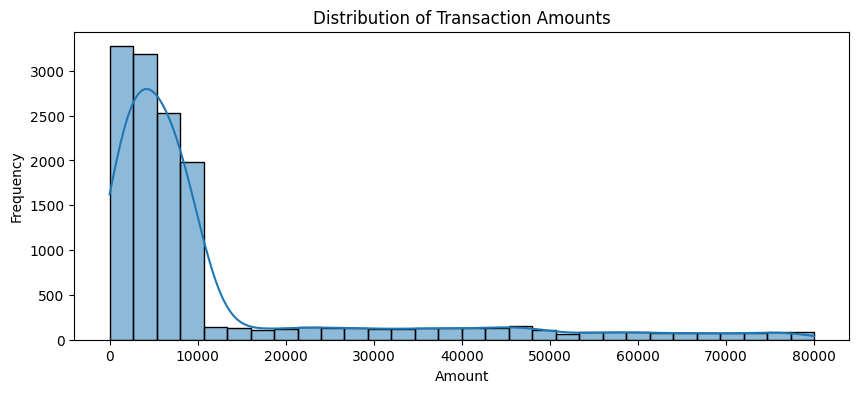

In [13]:
#histogram of the column "amount"
plt.figure(figsize=(10, 4))
sns.histplot(df["amount"], bins = 30, kde = True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show();

In [14]:
numeric

Index(['amount', 'year', 'month', 'quarter', 'is_high_value', 'is_weekend',
       'total_user_spending', 'avg_user_transaction'],
      dtype='object')

In [15]:
df["avg_user_transaction"]

,avg_user_transaction
0,8259.510870
1,12030.445783
2,11500.193878
3,12439.652174
4,11803.081395
...,...
13750,10519.523364
13751,8503.391753
13752,14941.111111
13753,11562.793103


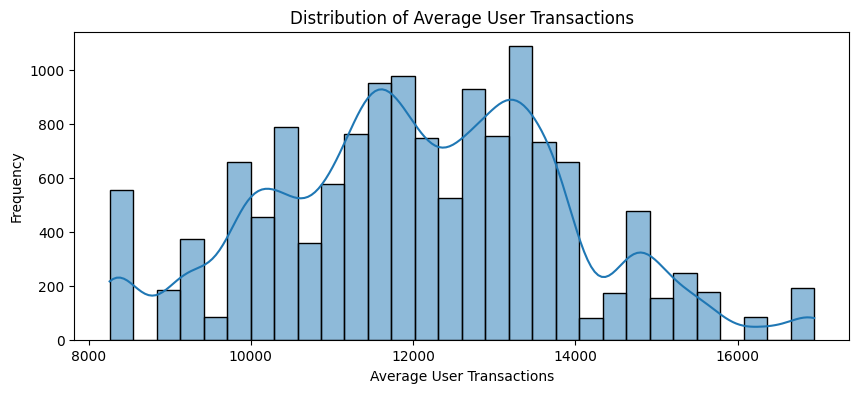

In [16]:
plt.figure(figsize=(10, 4))
sns.histplot(df["avg_user_transaction"], bins = 30, kde = True)
plt.title("Distribution of Average User Transactions")
plt.xlabel("Average User Transactions")
plt.ylabel("Frequency")
plt.show();

In [17]:
cat

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'payment_mode', 'location', 'month_name', 'day_of_week',
       'spending_level'],
      dtype='object')

In [18]:
df["category"]

,category
0,education
1,rent
2,freelance
3,entertainment
4,food
...,...
13750,food
13751,rent
13752,education
13753,food


/tmp/ipython-input-3081262692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "category", data = df, palette = "magma")


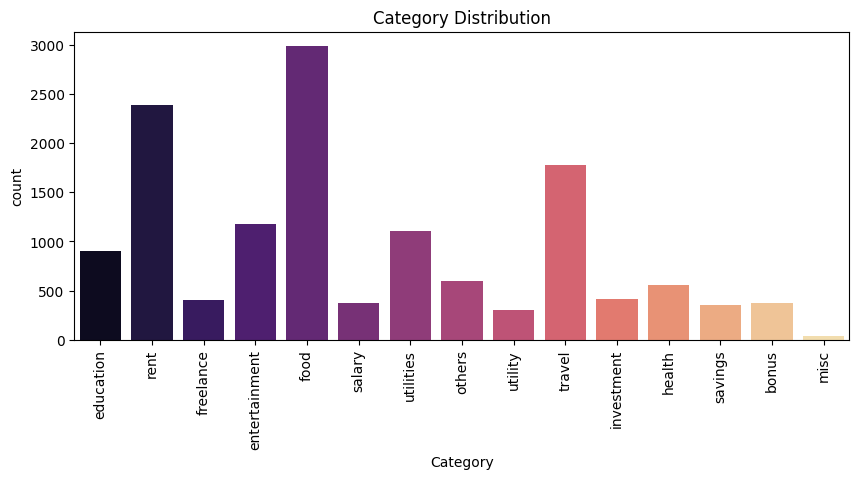

In [21]:
#category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "category", data = df, palette = "magma")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

/tmp/ipython-input-2183509001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "location", data = df, palette = "magma")


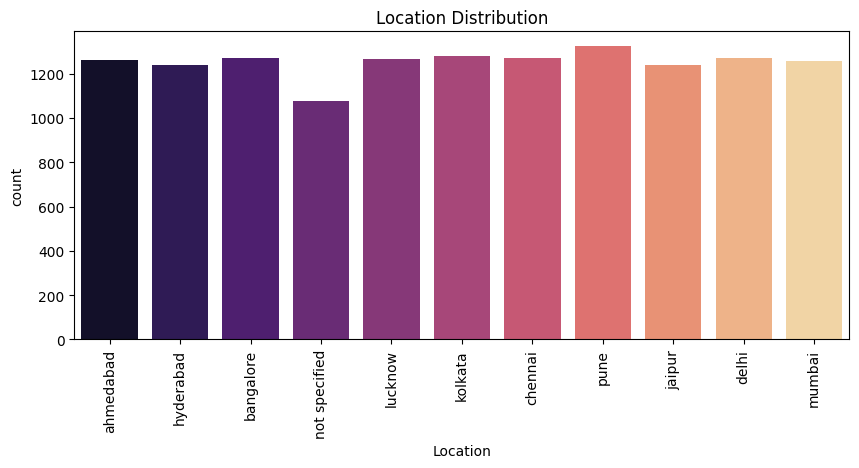

In [22]:
#location distribution
plt.figure(figsize = (10,4))
sns.countplot(x = "location", data = df, palette = "magma")
plt.title("Location Distribution")
plt.xlabel("Location")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

## **3. Bivariate Analysis**
Bivariate analysis = analyzing **two variables together**.

This helps answer questions like:
- Do some categories have higher spending?  
- What days have the highest spending?  
- Which payment method handles large amounts?  

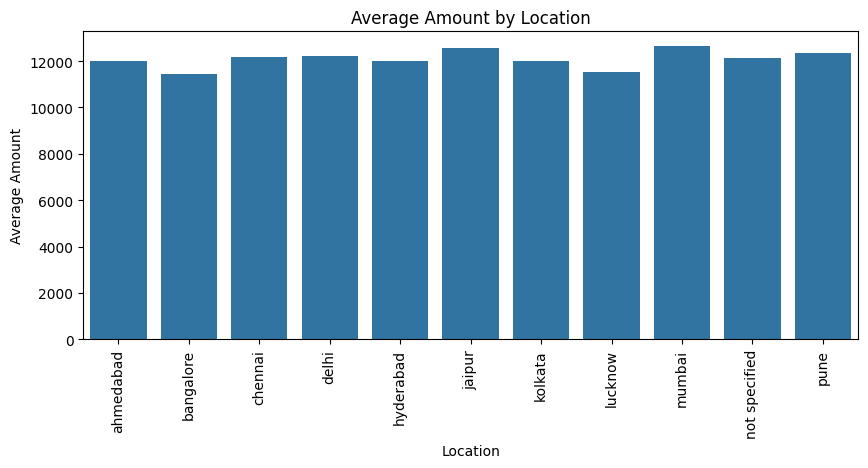

In [25]:
#location by amount
locat_amount = df.groupby("location")["amount"].mean()
plt.figure(figsize=(10,4))
sns.barplot(x = locat_amount.index, y = locat_amount.values)
plt.title("Average Amount by Location")
plt.xlabel("Location")
plt.ylabel("Average Amount")
plt.xticks(rotation = 90)
plt.show();

In [26]:
df["category"].value_counts()

,count
category,
food,2986
rent,2388
travel,1779
entertainment,1176
utilities,1111
education,903
others,599
health,552
investment,418


In [29]:
df.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,year,month,month_name,day_of_week,quarter,spending_level,is_high_value,is_weekend,total_user_spending,avg_user_transaction
0,T4999,U018,2023-04-25,Expense,education,3888,card,ahmedabad,2023,4,April,Tuesday,2,Medium,False,False,759875,8259.510870
1,T12828,U133,2021-12-16,Expense,rent,649,Unknown,hyderabad,2021,12,December,Thursday,4,Small,False,False,998527,12030.445783
2,T7403,U091,2021-12-16,Income,freelance,13239,Csh,bangalore,2021,12,December,Thursday,4,Large,True,False,1127019,11500.193878
3,T7495,U088,2021-12-16,Expense,entertainment,2287,CARD,hyderabad,2021,12,December,Thursday,4,Medium,False,False,1144448,12439.652174
4,T12465,U042,2021-12-16,Expense,food,4168,Unknown,not specified,2021,12,December,Thursday,4,Medium,False,False,1015065,11803.081395


In [30]:
df["transaction_type"].value_counts()

,count
transaction_type,
Expense,11758
Income,1997


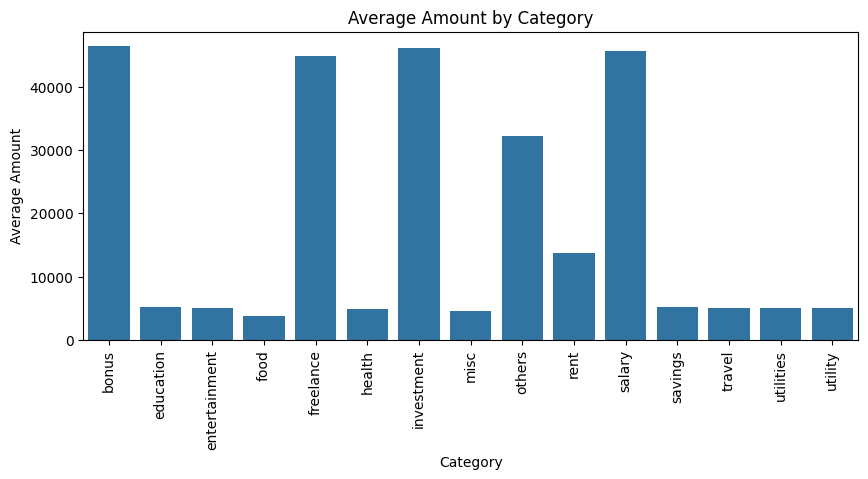

In [28]:
#category by amount
cat_amount = df.groupby("category")["amount"].mean()
plt.figure(figsize = (10,4))
sns.barplot(x = cat_amount.index, y = cat_amount.values)
plt.title("Average Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Amount")
plt.xticks(rotation = 90)
plt.show();

In [31]:
df.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'year', 'month', 'month_name',
       'day_of_week', 'quarter', 'spending_level', 'is_high_value',
       'is_weekend', 'total_user_spending', 'avg_user_transaction'],
      dtype='object')

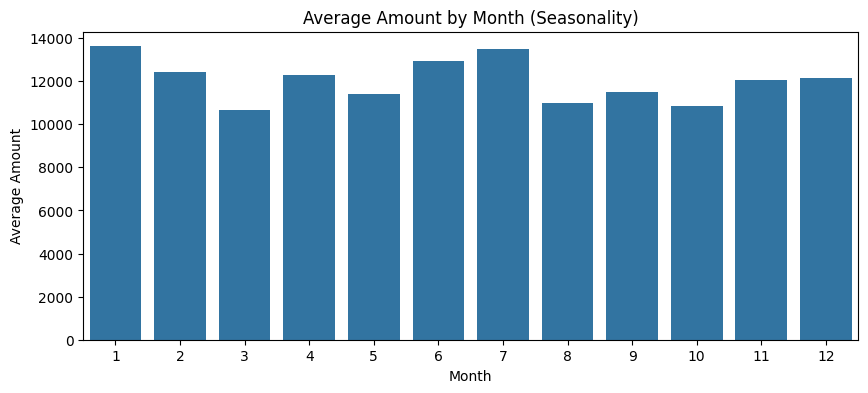

In [32]:
# seasonality by month-of-year (average across years)
#df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['amount'].mean()
plt.figure(figsize=(10,4))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title("Average Amount by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Amount")
plt.show();

In [33]:
#conditions - seperate the dataset into expenses and income
expenses = df[df["transaction_type"] == "Expense"]
expenses.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,year,month,month_name,day_of_week,quarter,spending_level,is_high_value,is_weekend,total_user_spending,avg_user_transaction
0,T4999,U018,2023-04-25,Expense,education,3888,card,ahmedabad,2023,4,April,Tuesday,2,Medium,False,False,759875,8259.510870
1,T12828,U133,2021-12-16,Expense,rent,649,Unknown,hyderabad,2021,12,December,Thursday,4,Small,False,False,998527,12030.445783
3,T7495,U088,2021-12-16,Expense,entertainment,2287,CARD,hyderabad,2021,12,December,Thursday,4,Medium,False,False,1144448,12439.652174
4,T12465,U042,2021-12-16,Expense,food,4168,Unknown,not specified,2021,12,December,Thursday,4,Medium,False,False,1015065,11803.081395
5,T4518,U026,2021-12-16,Expense,education,828,Crd,lucknow,2021,12,December,Thursday,4,Small,False,False,1137015,11370.150000


In [34]:
expenses["transaction_type"].value_counts()

,count
transaction_type,
Expense,11758


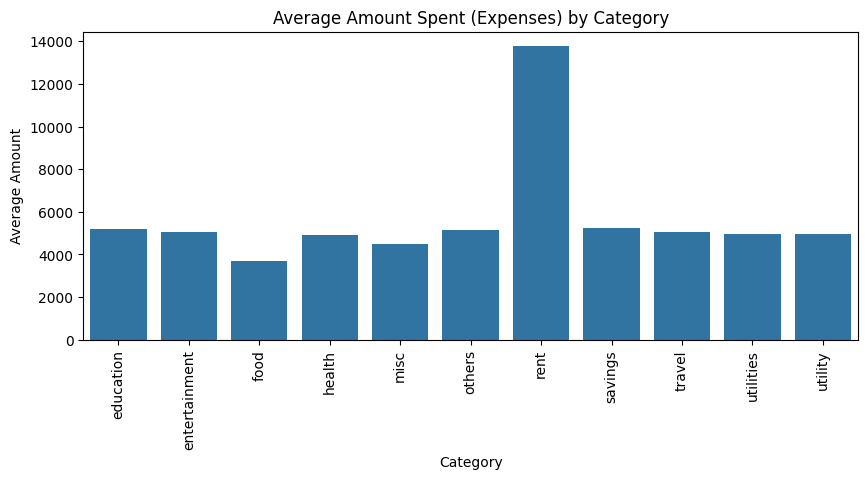

In [35]:
#category by amount
cat_amount_ = expenses.groupby("category")["amount"].mean()
plt.figure(figsize = (10,4))
sns.barplot(x = cat_amount_.index, y = cat_amount_.values)
plt.title("Average Amount Spent (Expenses) by Category")
plt.xlabel("Category")
plt.ylabel("Average Amount")
plt.xticks(rotation = 90)
plt.show();

In [36]:
#condition - income only dataset
income = df[df["transaction_type"] == "Income"]
income.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,year,month,month_name,day_of_week,quarter,spending_level,is_high_value,is_weekend,total_user_spending,avg_user_transaction
2,T7403,U091,2021-12-16,Income,freelance,13239,Csh,bangalore,2021,12,December,Thursday,4,Large,True,False,1127019,11500.193878
6,T9824,U061,2024-12-12,Income,salary,62061,CRD,ahmedabad,2024,12,December,Thursday,4,Large,True,False,1057802,12020.477273
8,T12403,U004,2021-12-16,Income,others,59543,UPI,lucknow,2021,12,December,Thursday,4,Large,True,False,1334617,12132.881818
13,T11382,U111,2021-12-16,Income,freelance,25143,card,chennai,2021,12,December,Thursday,4,Large,True,False,948234,11155.694118
15,T1982,U089,2021-02-27,Income,others,49683,Unknown,lucknow,2021,2,February,Saturday,1,Large,True,True,1060059,13250.737500


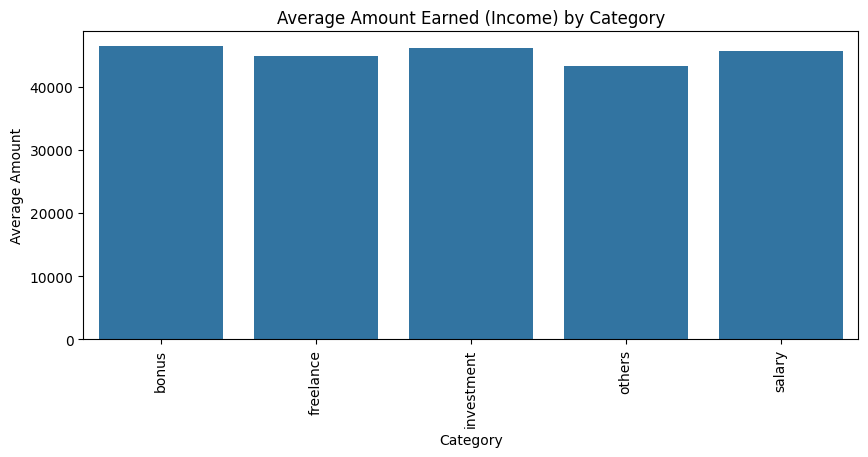

In [37]:
#category by amount
cat_amount_2 = income.groupby("category")["amount"].mean()
plt.figure(figsize = (10,4))
sns.barplot(x = cat_amount_2.index, y = cat_amount_2.values)
plt.title("Average Amount Earned (Income) by Category")
plt.xlabel("Category")
plt.ylabel("Average Amount")
plt.xticks(rotation = 90)
plt.show();

## **4. Outlier Identification**
Outliers matter because they may represent:
- Fraud  
- Errors  
- Extreme spending behavior  
- Business anomalies  

We use **boxplots** to visually detect them.


In [38]:
df["amount"]

,amount
0,3888
1,649
2,13239
3,2287
4,4168
...,...
13750,9952
13751,7335
13752,4353
13753,1048


In [40]:
#IQR-based outliers for amount column
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

outliers_amount = find_iqr_outliers(expenses['amount'].dropna())
print("IQR-based outliers in amount (count):", outliers_amount.shape[0])
display(outliers_amount.tail())

IQR-based outliers in amount (count): 692


,amount
13611,49284
13618,24568
13659,43714
13668,39449
13708,46947


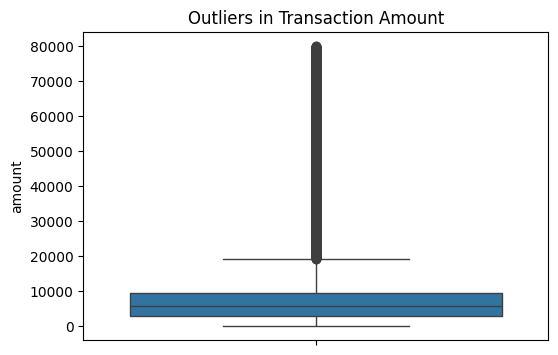

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(df["amount"])
plt.title("Outliers in Transaction Amount")
plt.show()


## **5. Correlation Analysis**
Correlation helps identify how numeric variables move together.

Why is it useful?
- Helps detect spending drivers  
- Helps reveal patterns  
- Helps prepare for modeling  


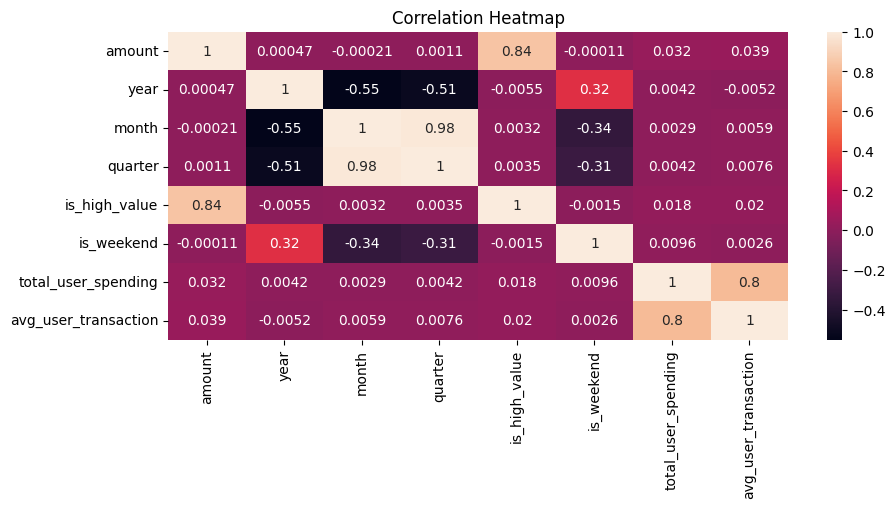

In [42]:
plt.figure(figsize = (10,4))
sns.heatmap(expenses.corr(numeric_only = True), annot = True)
plt.title("Correlation Heatmap")
plt.show();

## **6. Business Questions and Insights**

### **a. Which category has the highest spending?**
Use: groupby + bar chart

### **b. What days have the highest expenses?**
Use: date groupings

### **c. Does payment method influence spending amount?**

### **d. Is spending concentrated among a few locations or is it widely distributed?**
Use: groupby + boxplot

You must provide:
- Visual evidence  
- A written insight  

In [46]:
expenses.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,year,month,month_name,day_of_week,quarter,spending_level,is_high_value,is_weekend,total_user_spending,avg_user_transaction
0,T4999,U018,2023-04-25,Expense,education,3888,card,ahmedabad,2023,4,April,Tuesday,2,Medium,False,False,759875,8259.510870
1,T12828,U133,2021-12-16,Expense,rent,649,Unknown,hyderabad,2021,12,December,Thursday,4,Small,False,False,998527,12030.445783
3,T7495,U088,2021-12-16,Expense,entertainment,2287,CARD,hyderabad,2021,12,December,Thursday,4,Medium,False,False,1144448,12439.652174
4,T12465,U042,2021-12-16,Expense,food,4168,Unknown,not specified,2021,12,December,Thursday,4,Medium,False,False,1015065,11803.081395
5,T4518,U026,2021-12-16,Expense,education,828,Crd,lucknow,2021,12,December,Thursday,4,Small,False,False,1137015,11370.150000


In [47]:
expenses.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'year', 'month', 'month_name',
       'day_of_week', 'quarter', 'spending_level', 'is_high_value',
       'is_weekend', 'total_user_spending', 'avg_user_transaction'],
      dtype='object')

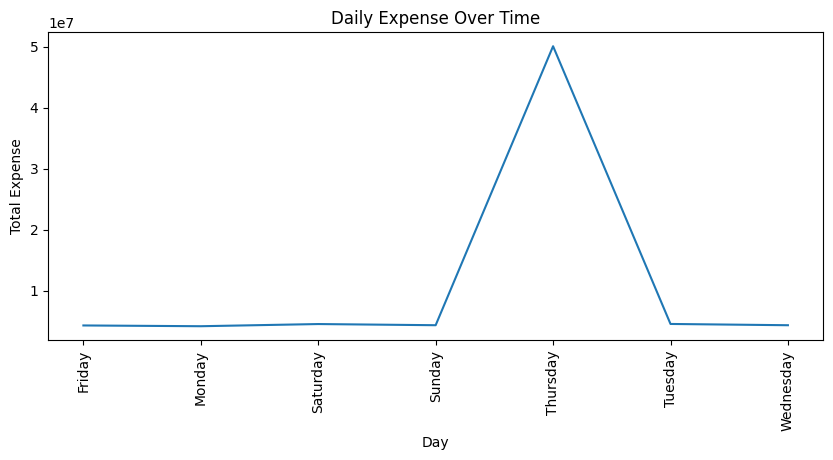

In [48]:
#b. what days have the highest expenses
daily_expense = expenses.groupby('day_of_week')['amount'].sum()
plt.figure(figsize=(10,4))
sns.lineplot(x=daily_expense.index, y=daily_expense.values)
plt.title("Daily Expense Over Time")
plt.xlabel("Day")
plt.xticks(rotation = 90)
plt.ylabel("Total Expense")
plt.show();

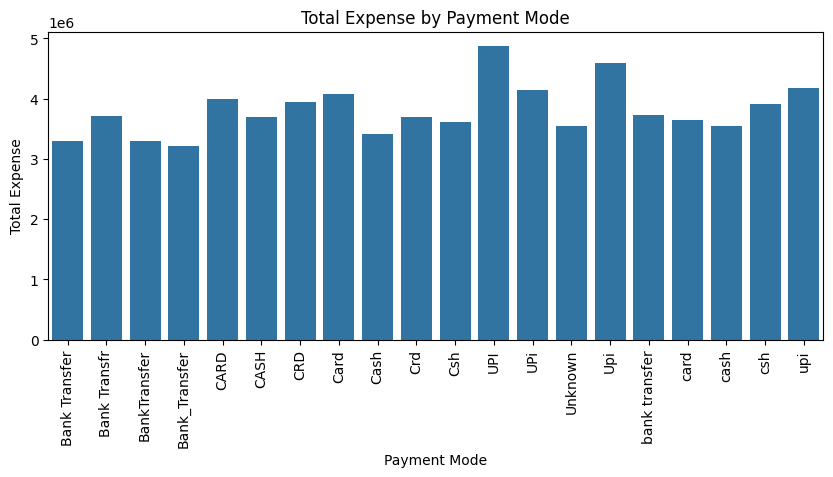

In [50]:
#c. which payment mode is used for high_value transactions
amount = expenses.groupby('payment_mode')['amount'].sum()
plt.figure(figsize=(10,4))
sns.barplot(x=amount.index, y=amount.values)
plt.title("Total Expense by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Expense")
plt.xticks(rotation = 90)
plt.show();


Q3: Location concentration


,amount
location,
delhi,7615692
kolkata,7238773
lucknow,7180668
bangalore,7130435
pune,6955090
chennai,6913127
mumbai,6895414
ahmedabad,6816781
hyderabad,6780299


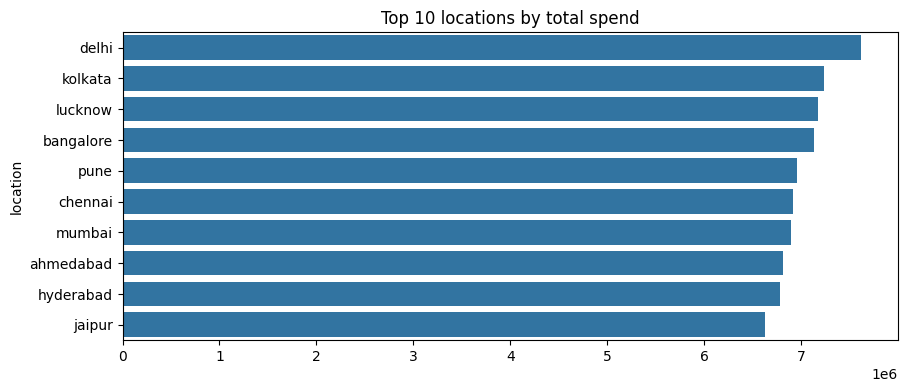

In [49]:
#d.
print("\nQ3: Location concentration")
loc_counts = expenses.groupby('location')['amount'].sum().sort_values(ascending=False)
display(loc_counts.head(10))
# visual: top 10 locations
plt.figure(figsize=(10,4))
sns.barplot(x=loc_counts.head(10).values, y=loc_counts.head(10).index)
plt.title("Top 10 locations by total spend")
plt.show()

## **Assignmnent**
Following what we have done today, perform Exploratory Data Analysis on your dataset - [Warehoue and Retail Sales Montgomery](https://www.kaggle.com/datasets/samanfatima7/warehouse-and-retail-sales-montgomery-county)

Study your dataset and perform
- Data overview and inspection
- Univariate analysis
- Bivariate analysis
- Correlation
- Outlier detection in numeric column(s)
- Answer three business questions developed by you.

Use the details below to **guide** you

### PART A - Data Overview & Inspection

1. Display the **first 5 rows** of the dataset.
2. Display the **last 5 rows** of the dataset.
3. Check:

   * Number of rows and columns
   * Column names
   * Data types
4. Use `.describe()` on numerical columns.
5. Answer:

   * Are there values that suggest possible outliers?
   * Which column(s) might contain unusually large values?



### PART B - Univariate Analysis

### Numerical Analysis

1. Select **one numerical column** related to sales or quantity.
2. Create:

   * A histogram
   * A boxplot
3. Write a short explanation:

   * What does the distribution look like?
   * Are there possible outliers?

### Categorical Analysis

1. Select **one categorical column** (e.g. product type, location, or warehouse).
2. Create a bar chart showing frequency.
3. Write a short explanation:

   * Which category appears most often?
   * What could this mean for the business?

### PART C - Bivariate Analysis

1. Choose:

   * One numerical column
   * One categorical column
2. Visualize their relationship (e.g. boxplot or grouped bar chart).
3. Answer:

   * Does spending/sales vary across categories?
   * Which category appears to generate higher values?

### PART D - Outlier Detection

1. Use:

   * `.describe()`
   * A boxplot
2. Identify whether outliers exist.
3. Answer:

   * Why might these outliers exist?
   * Are they likely errors or genuine business events?

### PART E - Correlation Analysis

1. Select **two numerical columns**.
2. Compute their correlation.
3. Answer:

   * Is the correlation weak, moderate, or strong?
   * How could this information be useful in business analysis?

### PART F - Business Questions & Insights

Develop and answer **THREE (3) business questions**, such as:

* Which warehouse/location records the highest sales?
* Are there products with consistently high sales?
* Are there periods with unusually high sales volumes?
* Which product category generates the most sales?
* Which store type performs better?
* Are there seasonal sales patterns?

For each question:

1. State the question clearly.
2. Use at least **one visualization** to support your answer.
3. Write a **short business insight**.

### Submission Requirements

* Push the notebook to your **GitHub repository**.
* Submit the **GitHub link** in the [submission sheet](https://docs.google.com/spreadsheets/d/1uIpd_jGrRRlQ1X9wx3XDzakWtKQ_cWMi7gB8eaQvXrs/edit?usp=sharing)
